# 03 — Feature Engineering
Build a modelling-ready dataset from raw match, player, and tournament data.

All features are computed **leak-free**: for each match we only use information
that was available *before* the match was played.

In [1]:
import sys
from pathlib import Path

# Make sure src/ is importable
repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.processing.features import compute_features

PROCESSED = repo_root / 'data' / 'processed'

df_matches     = pd.read_parquet(PROCESSED / 'matches.parquet')
df_players     = pd.read_parquet(PROCESSED / 'players.parquet')
df_tournaments = pd.read_parquet(PROCESSED / 'tournaments.parquet')

print(f'matches:     {df_matches.shape}')
print(f'players:     {df_players.shape}')
print(f'tournaments: {df_tournaments.shape}')

matches:     (5170, 16)
players:     (909, 12)
tournaments: (94, 9)


## 1. Compute Features

In [2]:
df_features = compute_features(
    df_matches,
    df_players,
    df_tournaments,
    window=20,
)

print(f'Feature matrix shape: {df_features.shape}')
print(f'Target balance — team_1 wins: {df_features["target"].mean():.1%}')
df_features.head()

Feature matrix shape: (891, 38)
Target balance — team_1 wins: 50.2%


,match_id,played_at,category,round,tournament_id,tournament_level,tournament_level_weight,elo_t1,elo_t2,elo_diff,...,matches_played_t2,matches_played_diff,h2h_wins_t1,h2h_wins_t2,h2h_total,h2h_win_rate_t1,ranking_t1,ranking_t2,ranking_diff,target
0,3867,2025-09-26,women,4,623,p2,3,1500.0,1500.0,0.0,...,0.0,0.0,0,0,0,0.5,12.0,3.5,8.5,0
1,3833,2025-09-26,men,4,623,p2,3,1500.0,1500.0,0.0,...,0.0,0.0,0,0,0,0.5,1.0,14.5,-13.5,1
2,3834,2025-09-26,men,4,623,p2,3,1500.0,1500.0,0.0,...,0.0,0.0,0,0,0,0.5,13.0,5.5,7.5,1
3,3835,2025-09-26,men,4,623,p2,3,1500.0,1500.0,0.0,...,0.0,0.0,0,0,0,0.5,8.5,10.5,-2.0,1
4,3866,2025-09-26,women,4,623,p2,3,1500.0,1500.0,0.0,...,0.0,0.0,0,0,0,0.5,7.5,13.0,-5.5,1


## 2. Data Quality

In [3]:
null_pct = (df_features.isnull().sum() / len(df_features) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]
print('Columns with nulls (%):')
print(null_pct.to_string() if len(null_pct) else 'None — clean dataset!')

Columns with nulls (%):
days_rest_diff    16.835017
days_rest_t2      11.335578
days_rest_t1      11.335578
ranking_diff       0.112233
ranking_t1         0.112233


## 3. ELO Distribution

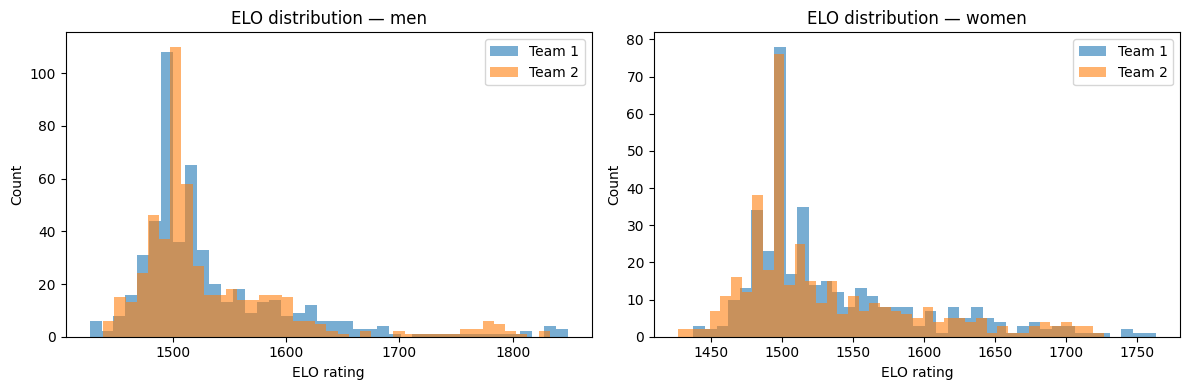

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, cat in zip(axes, ['men', 'women']):
    sub = df_features[df_features['category'] == cat]
    ax.hist(sub['elo_t1'], bins=40, alpha=0.6, label='Team 1')
    ax.hist(sub['elo_t2'], bins=40, alpha=0.6, label='Team 2')
    ax.set_title(f'ELO distribution — {cat}')
    ax.set_xlabel('ELO rating')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

## 4. Feature Distributions by Outcome

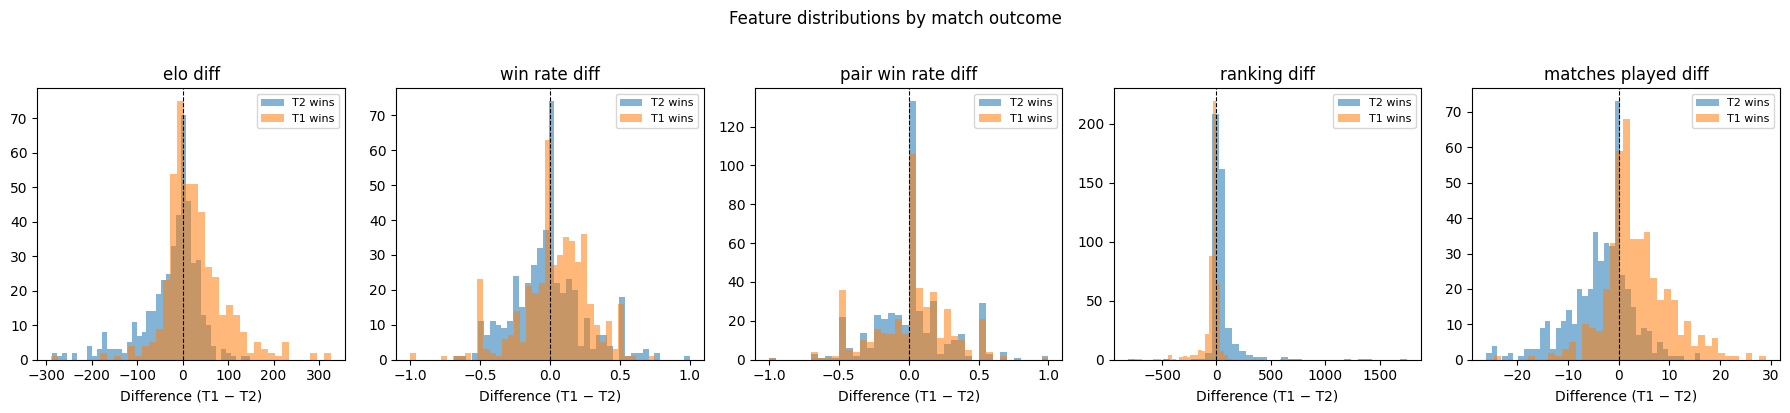

In [5]:
diff_features = ['elo_diff', 'win_rate_diff', 'pair_win_rate_diff', 'ranking_diff', 'matches_played_diff']

fig, axes = plt.subplots(1, len(diff_features), figsize=(18, 4))

for ax, feat in zip(axes, diff_features):
    for label, grp in df_features.groupby('target'):
        ax.hist(grp[feat].dropna(), bins=40, alpha=0.55,
                label='T1 wins' if label == 1 else 'T2 wins')
    ax.set_title(feat.replace('_', ' '))
    ax.set_xlabel('Difference (T1 − T2)')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.legend(fontsize=8)

plt.suptitle('Feature distributions by match outcome', y=1.02)
plt.tight_layout()
plt.show()

## 5. Feature Correlation

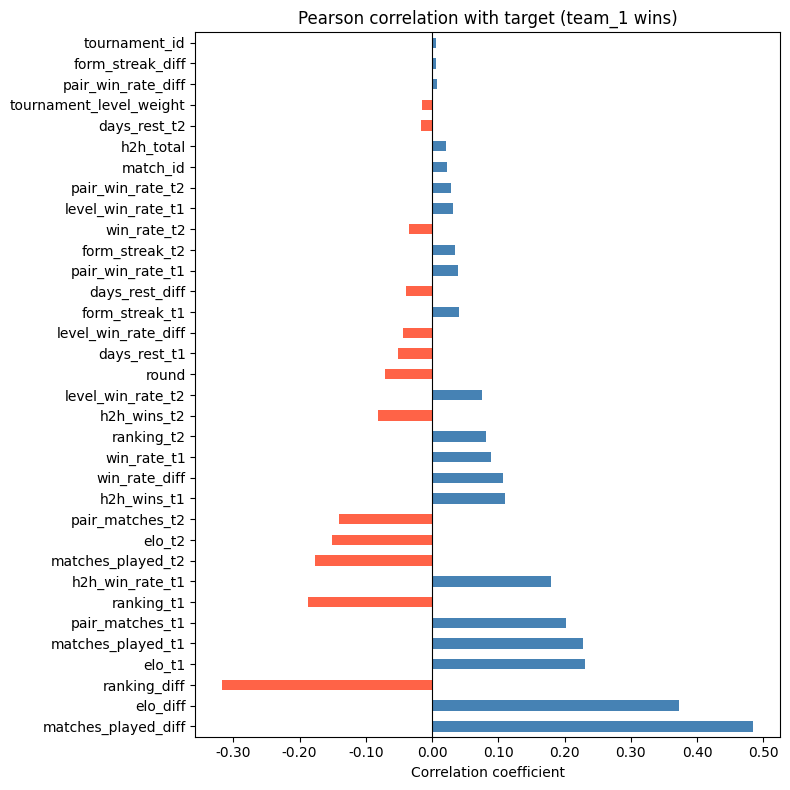

Top 5 most predictive features:
matches_played_diff    0.484877
elo_diff               0.372405
ranking_diff          -0.316882
elo_t1                 0.231492
matches_played_t1      0.227875
Name: target, dtype: float64


In [6]:
numeric_cols = df_features.select_dtypes(include='number').columns.tolist()
corr_with_target = (
    df_features[numeric_cols]
    .corr()['target']
    .drop('target')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['steelblue' if v > 0 else 'tomato' for v in corr_with_target]
corr_with_target.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson correlation with target (team_1 wins)')
ax.set_xlabel('Correlation coefficient')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.show()

print('Top 5 most predictive features:')
print(corr_with_target.head())

## 6. ELO Accuracy (Baseline)
How often does the higher ELO team win? This sets the floor for our ML model to beat.

In [7]:
elo_pred = (df_features['elo_diff'] > 0).astype(int)
elo_acc  = (elo_pred == df_features['target']).mean()

rank_pred = (df_features['ranking_diff'] < 0).astype(int)  # lower ranking = better
rank_acc  = (rank_pred == df_features['target']).dropna()
rank_acc  = (rank_pred[rank_acc.index] == df_features.loc[rank_acc.index, 'target']).mean()

print(f'ELO baseline accuracy:     {elo_acc:.1%}')
print(f'Ranking baseline accuracy: {rank_acc:.1%}')
print(f'Naive 50/50 baseline:       50.0%')
print()
print('Our ML model needs to beat these to be useful.')

ELO baseline accuracy:     64.2%
Ranking baseline accuracy: 80.5%
Naive 50/50 baseline:       50.0%

Our ML model needs to beat these to be useful.


## 7. Save to Parquet

In [8]:
out_path = PROCESSED / 'features.parquet'
df_features.to_parquet(out_path, index=False)
print(f'Saved {len(df_features)} rows × {len(df_features.columns)} columns → {out_path}')

Saved 891 rows × 38 columns → /Users/theodorsjetnanutvik/Desktop/personal-projects/padel-analytics/data/processed/features.parquet


In [9]:
print("matches.parquet shape:", df_matches.shape)
print("winner nulls:", df_matches['winner'].isna().sum())
print("winner values:", df_matches['winner'].value_counts())
print("t1_p1 nulls:", df_matches['t1_p1'].isna().sum())
print("t1_p2 nulls:", df_matches['t1_p2'].isna().sum())
print("played_at nulls:", df_matches['played_at'].isna().sum())
print("played_at dtype:", df_matches['played_at'].dtype)


matches.parquet shape: (5170, 16)
winner nulls: 0
winner values: winner
hidden_free_plan    4277
team_1               449
team_2               444
Name: count, dtype: int64
t1_p1 nulls: 58
t1_p2 nulls: 58
played_at nulls: 0
played_at dtype: datetime64[ns]
